# Annotation data preprocessing

Extracts all three sets at the **unit level** (SOL + student turns), each row
carrying the full MathDial record of its dialogue. Set membership is pinned
and unchanged; only the extraction schema is new.

- The development set is an **input frame only** (no label columns).
- The validation set carries **empty five-way gold columns** for the human
  annotator, plus an empty thread-table template, per the registered
  validation design (frozen codebook, cross-family five-way, ledger schema).
- The evaluation set begins with a seeded 20-dialogue draw, then supplements
  under-represented profile families until family coverage is even.
- Every generated CSV and membership file is create-only: if it already
  exists, the notebook reports that fact and leaves it unchanged.
- All source, membership, and generated set files live in
  `extension/artifacts/annotation_Dev_val_and_eval_sets/`.


## Section A — Setup

In [13]:
import os
from pathlib import Path

# Walk up to the repo root (folder containing data/annotated).
_here = Path.cwd()
for _c in [_here, *_here.parents]:
    if (_c / "data" / "annotated").exists():
        os.chdir(_c)
        break
else:
    raise FileNotFoundError("Could not find data/annotated above " + str(_here))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from extension.scripts.data_management.format_misconception_data import (
    ANNOTATION_COLUMNS,
    FAMILY_ORDER,
    add_annotation_columns,
    build_units,
    family_of,
    load_mathdial,
    validate_units,
)

DATA = Path("data/annotated")
SETS_DIR = Path("extension/artifacts/annotation_dev_val_and_eval_sets")
SETS_DIR.mkdir(parents=True, exist_ok=True)

print("working directory:", os.getcwd())


working directory: /Users/tandon.utsav2/Desktop/Experiment_1


### The six misconception families

The student profile collapses to six families. This mapping is the single source
of truth for family membership throughout the notebook.


In [14]:
print("families:", FAMILY_ORDER)

families: ['comprehension', 'principles', 'relevance', 'wrong-operation', 'steps', 'problem-type']


## Section B — Development set

`development_set_legacy.csv` preserves the original 55-dialogue membership (exracted during the intial phases of the project) and
its family coverage, and is read here only for that membership. The final
supplemented membership comes from the pinned `development_set_ids.json` when
that file exists; therefore rerunning the notebook does not redraw an
established set. The previously labelled subset is also identified so coverage
can be profiled for both.


In [15]:
DEV_CSV = SETS_DIR / "development_set_legacy.csv"  # preserved original set 
DEV_OUT = SETS_DIR / "development_set.csv"         # supplemented (complete) development set
dev = pd.read_csv(DEV_CSV, keep_default_na=False)

# Pinned ids: the definition of the development set.
dev_ids = sorted(dev["dialogue_id"].unique().tolist())
dev_dialogues = dev.drop_duplicates("dialogue_id")[["dialogue_id", "misconception_general"]].copy()
dev_dialogues["family"] = dev_dialogues["misconception_general"].apply(family_of)

# Labelled subset.
labelled_ids = sorted(dev.loc[dev["label"].str.strip() != "", "dialogue_id"].unique().tolist())
n_labelled_turns = int((dev["label"].str.strip() != "").sum())

print(f"development set: {len(dev_ids)} dialogues, {len(dev)} turns")
print(f"labelled: {len(labelled_ids)} dialogues, {n_labelled_turns} turns")
print(f"pinned ids: {dev_ids}")


development set: 55 dialogues, 308 turns
labelled: 0 dialogues, 0 turns
pinned ids: [37, 44, 96, 98, 188, 191, 319, 328, 523, 609, 680, 746, 748, 806, 887, 907, 927, 929, 977, 990, 1036, 1050, 1075, 1090, 1095, 1159, 1269, 1334, 1395, 1412, 1462, 1471, 1493, 1598, 1626, 1654, 1709, 1744, 1745, 1825, 1827, 1862, 1900, 1903, 1926, 1966, 1969, 2057, 2075, 2087, 2142, 2152, 2223, 2226, 2249]


### Original family coverage

The histogram shows how many dialogues each family contributes to the
original development set. Uneven coverage here is what the supplementation
step corrects.


full development set, dialogues per family:
family
comprehension       9
principles         11
relevance           5
wrong-operation     9
steps              13
problem-type        8


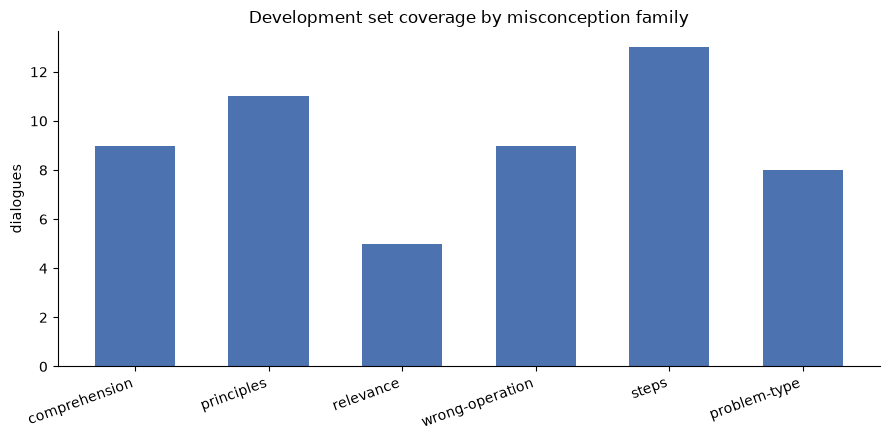

In [16]:
full_counts = (dev_dialogues["family"].value_counts()
                .reindex(FAMILY_ORDER, fill_value=0))

print("full development set, dialogues per family:")
print(full_counts.to_string())

x = np.arange(len(FAMILY_ORDER))
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x, full_counts.values, 0.6, color="#4C72B0")
ax.set_xticks(x); ax.set_xticklabels(FAMILY_ORDER, rotation=20, ha="right")
ax.set_ylabel("dialogues"); ax.set_title("Development set coverage by misconception family")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()


### Supplement under-represented families

To ensure enough examples per family, each family is topped up to a common
target number of dialogues by drawing from the untouched pool. The draw is
seeded and family-stratified, excludes every id already in the development set,
and (optionally) excludes a sealed held-out set so the two never overlap. Only
the shortfall is drawn: a family already at or above target adds nothing.


In [17]:
# Load the annotated source once; structured columns are parsed on read.
src = load_mathdial(DATA / "mathdial_train_atc.csv")
ID_COL = "index" if "index" in src.columns else src.columns[0]
src["family"] = src["student_profile"].apply(family_of)

def sample_by_family(excluded_ids, target, seed, existing_counts=None):
    """Draw a reproducible, family-balanced set outside `excluded_ids`."""
    available = src[~src[ID_COL].isin(set(excluded_ids))]
    existing_counts = existing_counts or {}
    rng = np.random.default_rng(seed)
    chosen = []
    for family in FAMILY_ORDER:
        have = int(existing_counts.get(family, 0))
        need = max(0, target - have)
        pool = available.loc[available["family"] == family, ID_COL].tolist()
        count = min(need, len(pool))
        picks = rng.choice(pool, size=count, replace=False) if count else []
        chosen.extend(int(dialogue_id) for dialogue_id in picks)
        print(f"  {family:18s} have {have:2d}  need {need:2d}  "
              f"pool {len(pool):3d}  drawing {count:2d}")
    return sorted(set(chosen))

# Development membership is pinned once created; otherwise supplement the original set.
TARGET_PER_FAMILY = 13
SEED = 11
HELDOUT_IDS_PATH = None   # optional JSON list of sealed dialogue ids
DEV_IDS_JSON = SETS_DIR / "development_set_ids.json"

if DEV_IDS_JSON.exists():
    with DEV_IDS_JSON.open() as handle:
        dev_extract_ids = sorted(json.load(handle)["dialogue_ids"])
    chosen = sorted(set(dev_extract_ids) - set(dev_ids))
    print(f"development ids from pinned file: {len(dev_extract_ids)} (no re-draw)")
else:
    excluded = set(dev_ids)
    if HELDOUT_IDS_PATH and Path(HELDOUT_IDS_PATH).exists():
        with Path(HELDOUT_IDS_PATH).open() as handle:
            excluded.update(json.load(handle))
    print(f"target {TARGET_PER_FAMILY} dialogues per family (seed {SEED})")
    chosen = sample_by_family(excluded, TARGET_PER_FAMILY, SEED,
                              full_counts.to_dict())
    dev_extract_ids = sorted(set(dev_ids) | set(chosen))

print(f"new dialogues added to the original set: {len(chosen)}")
print("new ids:", chosen)


development ids from pinned file: 78 (no re-draw)
new dialogues added to the original set: 23
new ids: [59, 163, 280, 308, 329, 547, 634, 852, 1035, 1064, 1143, 1202, 1219, 1420, 1538, 1639, 1830, 1967, 2063, 2090, 2150, 2233, 2236]


### Build the unit rows (the layout)

The shared formatter in `extension/scripts/data_management/format_misconception_data.py`
produces one row per **unit**: a `solution` row followed by one row per
student turn. Each row carries a readable spine and then the full MathDial
record.

- **Identity and descriptors.** `dialogue_id`; `turn` (`solution` or
  `turn n`); the native MathDial descriptors `student_profile`,
  `teacher_described_confusion`, `question`, `student_incorrect_solution`.
- **Context and content.** `dialogue_history` holds the exchange before this
  response, ending on the tutor turn that prompts it (empty for the solution
  row); `student_turn_text` holds the unit's own text.
- **Turn-level annotation.** `correct` and `kcs` come from the per-turn ATC
  annotation (guarded against error records). The solution row carries
  `correct=False`, the dataset's by-construction value, and no `kcs`, since
  the source assigns the solution none.
- **Tail.** The remaining MathDial fields copied unchanged, the `family`
  mapping, and `conversation`: the causal prefix rendered as a readable
  transcript (`Tutor:` the problem, `Student (turn 0):` the solution, then
  the dialogue through this row's turn inclusive), so the solution row's
  `conversation` is the problem plus solution and the final row's is the
  full dialogue.


In [18]:
# All annotation sets share one ordered schema; development starts blank.
dev_units = add_annotation_columns(
    build_units(src, dev_extract_ids, solution_kcs="blank")
)
dev_audit = validate_units(
    dev_units, solution_kcs="blank", expected_dialogues=len(dev_extract_ids)
)
dev_annotation_values = (
    dev_units[ANNOTATION_COLUMNS].fillna("").astype(str)
    .apply(lambda column: column.str.strip())
)
assert dev_annotation_values.eq("").all().all(), (
    "development annotation columns must start blank"
)
print(f"development extraction: {dev_units['dialogue_id'].nunique()} dialogues, "
      f"{len(dev_units)} rows (incl. solution rows)")

_turn_rows = dev_units[dev_units["turn"] != "solution"]
if len(_turn_rows) and (_turn_rows["correct"].astype(str).str.strip() == "").all():
    _raw = src.set_index(ID_COL).loc[dev_extract_ids[0]].get("annotation")
    print("WARNING: correct/kcs empty on every turn row. "
          "Raw annotation sample from the first dialogue:")
    print(repr(_raw)[:600])



development extraction: 78 dialogues, 516 rows (incl. solution rows)


### Post-extraction coverage

Family coverage of the final supplemented set, plotted beside the original
membership so the supplementation's effect is visible per family.


development dialogues per family (re-extracted):
family
comprehension      13
principles         13
relevance          13
wrong-operation    13
steps              13
problem-type       13

rows: 516 across 78 dialogues (median 6 units per dialogue, incl. solution)


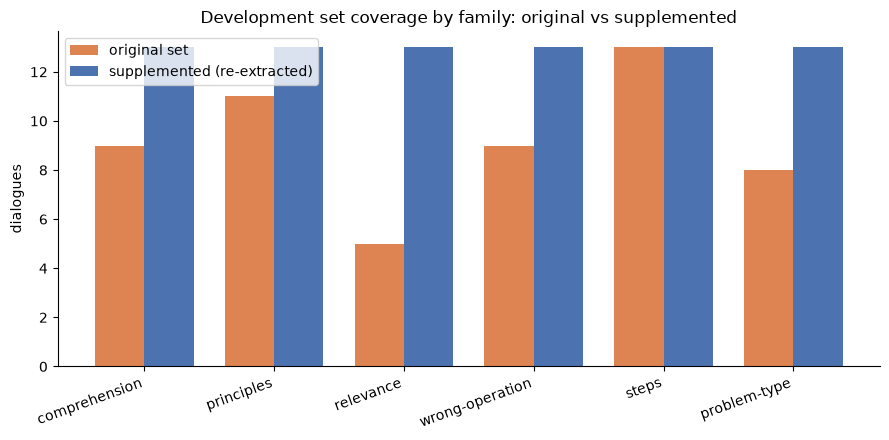

In [19]:
dev_cov = (dev_units.drop_duplicates("dialogue_id")["family"]
           .value_counts().reindex(FAMILY_ORDER, fill_value=0))
print("development dialogues per family (re-extracted):")
print(dev_cov.to_string())

units_per = dev_units.groupby("dialogue_id")["turn"].nunique()
print(f"\nrows: {len(dev_units)} across {dev_units['dialogue_id'].nunique()} "
      f"dialogues (median {int(units_per.median())} units per dialogue, incl. solution)")

x = np.arange(len(FAMILY_ORDER)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - w/2, full_counts.values, w, label="original set", color="#DD8452")
ax.bar(x + w/2, dev_cov.values, w, label="supplemented (re-extracted)", color="#4C72B0")
ax.set_xticks(x); ax.set_xticklabels(FAMILY_ORDER, rotation=20, ha="right")
ax.set_ylabel("dialogues")
ax.set_title("Development set coverage by family: original vs supplemented")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()


### Save the re-extracted development set

Development uses the same ordered columns as validation and evaluation. Its
12 annotation columns are added blank; a blank means unannotated, not absent.
Both the CSV and pinned membership file are create-only. Before saving, the notebook verifies
both development CSVs: `development_set_legacy.csv` must exactly match the 55
original notebook IDs, and all 55 must be retained in the supplemented
`development_set.csv`. The full CSV membership, row count, and schema are also
checked before an existing file is skipped.


In [20]:
saved_legacy_development = pd.read_csv(DEV_CSV)
saved_legacy_ids = sorted(
    saved_legacy_development["dialogue_id"].astype(int).unique().tolist()
)
assert saved_legacy_ids == dev_ids, (
    "development_set_legacy.csv does not match the original notebook IDs"
)
missing_legacy_ids = sorted(set(dev_ids) - set(dev_extract_ids))
assert not missing_legacy_ids, (
    f"supplemented development membership dropped legacy IDs: {missing_legacy_ids}"
)
supplemented_dev_ids = sorted(set(dev_extract_ids) - set(dev_ids))
assert supplemented_dev_ids == sorted(chosen), (
    "notebook's reported supplementation differs from the full membership"
)
print(f"legacy membership confirmed: all {len(dev_ids)} original IDs match "
      f"{DEV_CSV}")
print(f"full development membership: {len(dev_extract_ids)} IDs = "
      f"{len(dev_ids)} legacy + {len(supplemented_dev_ids)} supplemented")

if DEV_IDS_JSON.exists():
    with DEV_IDS_JSON.open() as handle:
        pinned_development = json.load(handle)
    pinned_dev_ids = sorted(int(i) for i in pinned_development["dialogue_ids"])
    assert pinned_development["seed"] == SEED
    assert pinned_development["target_per_family"] == TARGET_PER_FAMILY
    assert pinned_dev_ids == dev_extract_ids, (
        f"reconstructed development membership differs from pinned IDs; "
        f"notebook-only={sorted(set(dev_extract_ids) - set(pinned_dev_ids))}, "
        f"pinned-only={sorted(set(pinned_dev_ids) - set(dev_extract_ids))}"
    )
    print(f"exact reproduction confirmed: all {len(dev_extract_ids)} development "
          f"IDs match {DEV_IDS_JSON}")

if DEV_OUT.exists():
    saved_development = pd.read_csv(DEV_OUT)
    saved_development_ids = sorted(
        saved_development["dialogue_id"].astype(int).unique().tolist()
    )
    assert saved_development_ids == dev_extract_ids, (
        "existing development CSV does not match the reconstructed membership"
    )
    assert len(saved_development) == len(dev_units), (
        "existing development CSV has a different number of unit rows"
    )
    assert saved_development.columns.tolist() == dev_units.columns.tolist(), (
        "existing development CSV schema differs from the reconstructed schema"
    )
    print(f"SKIPPING {DEV_OUT}: file already exists.")
else:
    dev_units.to_csv(DEV_OUT, index=False, mode="x")
    print(f"written {DEV_OUT} ({len(dev_units)} unit rows)")

if DEV_IDS_JSON.exists():
    print(f"SKIPPING {DEV_IDS_JSON}: file already exists.")
else:
    with DEV_IDS_JSON.open("x") as handle:
        json.dump({"seed": SEED, "target_per_family": TARGET_PER_FAMILY,
                   "dialogue_ids": dev_extract_ids}, handle, indent=2)
    print(f"written {DEV_IDS_JSON} ({len(dev_extract_ids)} ids)")

legacy membership confirmed: all 55 original IDs match extension/artifacts/annotation_dev_val_and_eval_sets/development_set_legacy.csv
full development membership: 78 IDs = 55 legacy + 23 supplemented
exact reproduction confirmed: all 78 development IDs match extension/artifacts/annotation_dev_val_and_eval_sets/development_set_ids.json
SKIPPING extension/artifacts/annotation_dev_val_and_eval_sets/development_set.csv: file already exists.
SKIPPING extension/artifacts/annotation_dev_val_and_eval_sets/development_set_ids.json: file already exists.


## Section C — Validation set

This section mirrors the development workflow: it reruns the historical
seed-23, family-stratified draw after excluding every development dialogue,
prints the selected IDs, and plots family coverage. It then reconstructs the
unit-level validation frame. Existing validation artifacts are checked and
left untouched; a CSV or membership JSON is written only when it is absent.


In [21]:
VAL_TARGET_PER_FAMILY = 13
VAL_SEED = 23
VAL_IDS_JSON = SETS_DIR / "validation_set_ids.json"
VAL_OUT = SETS_DIR / "validation_set.csv"

dev_id_set = set(dev_extract_ids)

print(f"validation target {VAL_TARGET_PER_FAMILY} per family (seed {VAL_SEED})")
val_chosen = sample_by_family(
    dev_id_set, VAL_TARGET_PER_FAMILY, VAL_SEED
)

overlap = set(val_chosen) & dev_id_set
assert not overlap, f"validation overlaps development: {sorted(overlap)}"
print(f"validation dialogues: {len(val_chosen)}; no-overlap check passed")
print("validation dialogue ids:")
print(val_chosen)


validation target 13 per family (seed 23)
  comprehension      have  0  need 13  pool 400  drawing 13
  principles         have  0  need 13  pool 372  drawing 13
  relevance          have  0  need 13  pool 316  drawing 13
  wrong-operation    have  0  need 13  pool 375  drawing 13
  steps              have  0  need 13  pool 357  drawing 13
  problem-type       have  0  need 13  pool 355  drawing 13
validation dialogues: 78; no-overlap check passed
validation dialogue ids:
[1, 21, 35, 79, 143, 178, 255, 270, 275, 289, 300, 306, 323, 344, 351, 356, 380, 434, 448, 494, 532, 554, 589, 617, 635, 656, 695, 736, 758, 779, 818, 822, 842, 862, 947, 958, 966, 980, 992, 1026, 1051, 1063, 1071, 1084, 1089, 1107, 1119, 1217, 1221, 1300, 1349, 1421, 1452, 1490, 1519, 1540, 1553, 1555, 1557, 1571, 1615, 1658, 1668, 1717, 1719, 1776, 1780, 1870, 1890, 1916, 1941, 2018, 2164, 2192, 2196, 2202, 2206, 2222]


### Validation family coverage

Dialogues per native profile family in the reproduced seeded draw. Because
selection is family-stratified, each bar should reach the target unless the
available pool for a family is exhausted.


validation dialogues per family:
family
comprehension      13
principles         13
relevance          13
wrong-operation    13
steps              13
problem-type       13


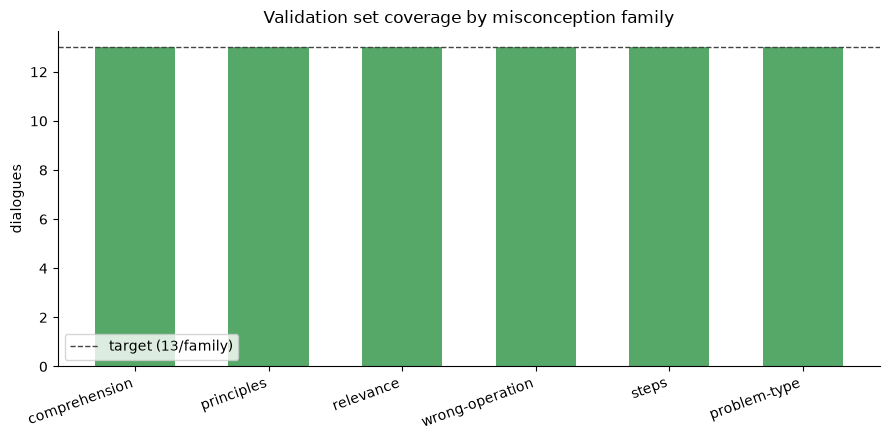

In [22]:
val_fam = (src.set_index(ID_COL).loc[val_chosen, "family"]
           .value_counts().reindex(FAMILY_ORDER, fill_value=0))
print("validation dialogues per family:")
print(val_fam.to_string())

x = np.arange(len(FAMILY_ORDER))
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x, val_fam.values, 0.6, color="#55A868")
ax.axhline(VAL_TARGET_PER_FAMILY, color="#444444", linewidth=1,
           linestyle="--", label=f"target ({VAL_TARGET_PER_FAMILY}/family)")
ax.set_xticks(x); ax.set_xticklabels(FAMILY_ORDER, rotation=20, ha="right")
ax.set_ylabel("dialogues")
ax.set_title("Validation set coverage by misconception family")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()


### Build the validation set — annotation format

The shared formatter first creates the same unit-row layout described in
Section B: one `solution` row followed by one row per student turn. Validation
then adds a human-gold annotation surface. These additional columns start
blank; a blank is an unannotated value, not a negative judgment.

The annotation surface has four parts.

**Judgment columns** (`comprehension`, `relevance`, `principles`,
`wrong_operation`, `steps`) — exactly one of `P`, `A`, or `N` per completed
cell: present, absent, or not assessable. Nothing else belongs in these
columns.

**Source columns** (`comprehension_src`, `relevance_src`, `principles_src`,
`wrong_operation_src`, `steps_src`) — thread attribution for the matching
judgment cell, with defaults chosen so most cells remain blank:

- `P` with blank source is allowed only when the dialogue has exactly one
  thread in that family, so its source can be inferred. With multiple
  same-family threads, the source is required (`S1`, or `S1|S2` for layered
  exhibition).
- `A` with blank source records thread-independent credit, such as the
  symmetric and re-articulation standards.
- `A` with a source such as `S1` records a resolution: the student's own act
  commits the corrected counterpart of that thread's belief.
- `N` always has a blank source.

**`dialogue_threads`** — misconception metadata for the whole dialogue,
repeated on every row for readability. The solution row is authoritative:
downstream assembly reads the value there, broadcasts it to the turn rows, and
warns if a turn contains a different non-empty value. Thread segments are
separated by `||` and use this grammar:

```text
S1: family=comprehension; belief=<one line>; signature=<quantity/operand/omission + role>;
    origin=solution; kind=initial; resolved_at=turn 5 || S2: family=...
```

- `family` — one of the five misconception families.
- `belief` — the enacted belief, stated once.
- `signature` — the evidence used to match later re-emergence.
- `origin` — `solution` or `turn n`.
- `kind` — `initial`, `re-attribution`, or `post-expiry`.
- `resolved_at` — the resolving turn; omitted if unresolved.

Exhibition histories are derived from the grid: a thread is exhibited at turns
whose judgment is `P` and whose source, explicit or inferred, includes its ID.
The `note` column is reserved for genuine residue, such as salient event tags
or echo/dictation observations.


In [23]:
val_units = add_annotation_columns(
    build_units(src, val_chosen, solution_kcs="blank")
)
validate_units(
    val_units, solution_kcs="blank", expected_dialogues=len(val_chosen)
)
validation_blank_columns = list(ANNOTATION_COLUMNS)
assert val_units[validation_blank_columns].fillna("").astype(str).apply(
    lambda column: column.str.strip().eq("").all()
).all(), "validation annotation columns must start blank"
assert val_units.columns.tolist() == dev_units.columns.tolist(), (
    "development and validation schemas must match exactly"
)
print(f"validation extraction: {val_units['dialogue_id'].nunique()} dialogues, "
      f"{len(val_units)} rows (incl. solution rows)")
print(f"shared schema: {len(val_units.columns)} columns; "
      f"{len(validation_blank_columns)} annotation columns start blank")


validation extraction: 78 dialogues, 544 rows (incl. solution rows)
shared schema: 30 columns; 12 annotation columns start blank


### Save the validation set

The reconstructed frame is saved to `validation_set.csv`, while the seed,
target, exclusions, and selected dialogue IDs are pinned in
`validation_set_ids.json`. Both files are create-only. If a file already
exists, the notebook verifies its membership and schema and leaves it
unchanged.


In [24]:
if VAL_IDS_JSON.exists():
    with VAL_IDS_JSON.open() as handle:
        pinned_validation = json.load(handle)
    pinned_val_ids = sorted(int(i) for i in pinned_validation["dialogue_ids"])
    assert pinned_validation["seed"] == VAL_SEED
    assert pinned_validation["target_per_family"] == VAL_TARGET_PER_FAMILY
    assert set(pinned_validation["excludes_development_ids"]) == dev_id_set
    assert pinned_val_ids == val_chosen, (
        f"reproduced validation membership differs from pinned IDs; "
        f"draw-only={sorted(set(val_chosen) - set(pinned_val_ids))}, "
        f"pinned-only={sorted(set(pinned_val_ids) - set(val_chosen))}"
    )
    print(f"exact reproduction confirmed: all {len(val_chosen)} drawn IDs "
          f"match {VAL_IDS_JSON}")

if VAL_OUT.exists():
    saved_validation = pd.read_csv(VAL_OUT)
    saved_validation_ids = sorted(
        saved_validation["dialogue_id"].astype(int).unique().tolist()
    )
    assert saved_validation_ids == val_chosen, (
        "existing validation CSV does not match the reproduced membership"
    )
    assert len(saved_validation) == len(val_units), (
        "existing validation CSV has a different number of unit rows"
    )
    saved_validation_columns = saved_validation.columns.tolist()
    assert saved_validation_columns == val_units.columns.tolist(), (
        "existing validation CSV schema differs from the reconstructed schema"
    )
    print(f"SKIPPING {VAL_OUT}: file already exists.")
else:
    val_units.to_csv(VAL_OUT, index=False, mode="x")
    print(f"written {VAL_OUT} ({len(val_units)} unit rows)")

if VAL_IDS_JSON.exists():
    print(f"SKIPPING {VAL_IDS_JSON}: file already exists.")
else:
    validation_membership = {
        "seed": VAL_SEED,
        "target_per_family": VAL_TARGET_PER_FAMILY,
        "dialogue_ids": val_chosen,
        "excludes_development_ids": sorted(dev_id_set),
    }
    with VAL_IDS_JSON.open("x") as handle:
        json.dump(validation_membership, handle, indent=2)
    print(f"written {VAL_IDS_JSON} ({len(val_chosen)} ids)")


exact reproduction confirmed: all 78 drawn IDs match extension/artifacts/annotation_dev_val_and_eval_sets/validation_set_ids.json
SKIPPING extension/artifacts/annotation_dev_val_and_eval_sets/validation_set.csv: file already exists.
SKIPPING extension/artifacts/annotation_dev_val_and_eval_sets/validation_set_ids.json: file already exists.


## Section D — Evaluation set

The evaluation set is a final held-out human-annotation surface. Like the
validation set, it is selected with one reproducible family-stratified draw.
Seed 37 draws 6 dialogues from each of MathDial's 6 native profile families,
giving 36 evaluation dialogues in total. Every development and validation ID
is excluded before sampling, and the three memberships are asserted disjoint.

Evaluation uses the same empty judgment, source, thread, and note
columns as validation. Its CSV and membership JSON remain create-only: an
existing artifact is checked and never overwritten.


In [25]:
EVAL_TARGET_PER_FAMILY = 6
EVAL_SEED = 37
EVAL_IDS_JSON = SETS_DIR / "evaluation_set_ids.json"
EVAL_OUT = SETS_DIR / "evaluation_set.csv"

evaluation_excluded_ids = dev_id_set | set(val_chosen)

print(f"evaluation target {EVAL_TARGET_PER_FAMILY} per family "
      f"(seed {EVAL_SEED})")
eval_chosen = sample_by_family(
    evaluation_excluded_ids, EVAL_TARGET_PER_FAMILY, EVAL_SEED
)

expected_evaluation_dialogues = EVAL_TARGET_PER_FAMILY * len(FAMILY_ORDER)
assert len(eval_chosen) == expected_evaluation_dialogues
eval_overlap = set(eval_chosen) & evaluation_excluded_ids
assert not eval_overlap, (
    f"evaluation overlaps development or validation: {sorted(eval_overlap)}"
)
print(f"evaluation dialogues: {len(eval_chosen)}; no-overlap check passed")
print("evaluation dialogue ids:")
print(eval_chosen)


evaluation target 6 per family (seed 37)
  comprehension      have  0  need  6  pool 387  drawing  6
  principles         have  0  need  6  pool 359  drawing  6
  relevance          have  0  need  6  pool 303  drawing  6
  wrong-operation    have  0  need  6  pool 362  drawing  6
  steps              have  0  need  6  pool 344  drawing  6
  problem-type       have  0  need  6  pool 342  drawing  6
evaluation dialogues: 36; no-overlap check passed
evaluation dialogue ids:
[41, 48, 105, 141, 158, 263, 296, 413, 446, 496, 508, 518, 570, 588, 623, 642, 650, 693, 844, 985, 1019, 1220, 1348, 1407, 1492, 1497, 1502, 1574, 1652, 1659, 1708, 1793, 1933, 2070, 2182, 2234]


### Evaluation family coverage

Dialogues per native profile family in the seeded draw. Because selection is
family-stratified, every bar should reach the target of 6 dialogues.


evaluation dialogues per family:
family
comprehension      6
principles         6
relevance          6
wrong-operation    6
steps              6
problem-type       6


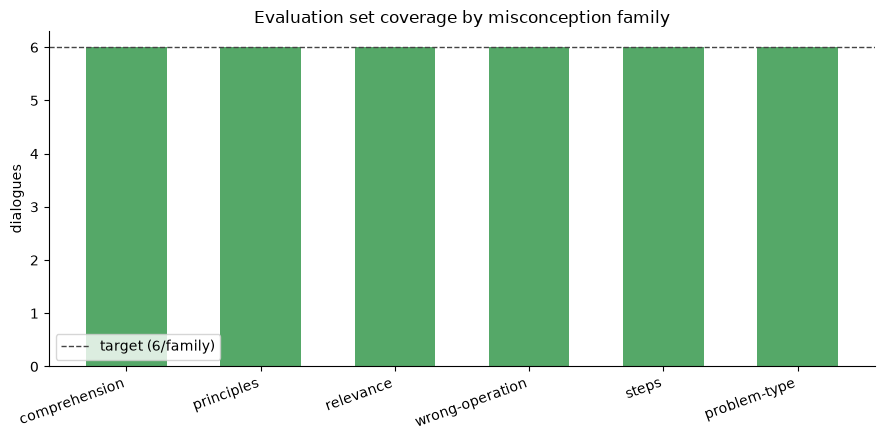

In [26]:
eval_fam = (
    src.set_index(ID_COL).loc[eval_chosen, "family"]
    .value_counts().reindex(FAMILY_ORDER, fill_value=0)
)
assert (eval_fam == EVAL_TARGET_PER_FAMILY).all(), (
    f"evaluation set is not balanced at {EVAL_TARGET_PER_FAMILY} per family:\n"
    f"{eval_fam.to_string()}"
)
print("evaluation dialogues per family:")
print(eval_fam.to_string())

x = np.arange(len(FAMILY_ORDER))
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x, eval_fam.values, 0.6, color="#55A868")
ax.axhline(
    EVAL_TARGET_PER_FAMILY, color="#444444", linewidth=1, linestyle="--",
    label=f"target ({EVAL_TARGET_PER_FAMILY}/family)",
)
ax.set_xticks(x); ax.set_xticklabels(FAMILY_ORDER, rotation=20, ha="right")
ax.set_ylabel("dialogues")
ax.set_title("Evaluation set coverage by misconception family")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()


### Confirm the held-out evaluation membership

The direct draw must contain exactly 36 unique dialogues and remain disjoint
from both development and validation. These assertions run independently of
the later file-saving checks.


In [27]:
assert len(eval_chosen) == 36
assert len(eval_chosen) == len(set(eval_chosen))
assert set(eval_chosen).isdisjoint(dev_id_set)
assert set(eval_chosen).isdisjoint(val_chosen)
assert set(dev_id_set).isdisjoint(val_chosen)
print("development, validation, and evaluation memberships are disjoint")


development, validation, and evaluation memberships are disjoint


### Build the evaluation set

The formatter supplies the shared 30-column schema directly. The assertions
verify that development, validation, and evaluation use the exact same ordered
header and that every newly constructed annotation field begins blank.


In [28]:
eval_units = add_annotation_columns(
    build_units(src, eval_chosen, solution_kcs="blank")
)
eval_audit = validate_units(
    eval_units, solution_kcs="blank", expected_dialogues=len(eval_chosen)
)

if not VAL_OUT.exists():
    raise FileNotFoundError(
        f"evaluation formatting requires the saved validation schema at {VAL_OUT}"
    )
validation_schema_columns = pd.read_csv(VAL_OUT, nrows=0).columns.tolist()
shared_schema_columns = dev_units.columns.tolist()
assert validation_schema_columns == shared_schema_columns, (
    "saved validation schema must match development exactly"
)
assert eval_units.columns.tolist() == shared_schema_columns, (
    "evaluation schema must match development and validation exactly"
)

evaluation_blank_columns = list(ANNOTATION_COLUMNS)
eval_annotation_values = (
    eval_units[evaluation_blank_columns].fillna("").astype(str)
    .apply(lambda column: column.str.strip())
)
assert eval_annotation_values.eq("").all().all(), (
    "evaluation annotation columns must all be blank"
)

print(
    f"evaluation set: {eval_units['dialogue_id'].nunique()} dialogues, "
    f"{len(eval_units)} rows"
)
print(
    f"shared development/validation/evaluation schema: "
    f"{len(eval_units.columns)} columns "
    f"({len(evaluation_blank_columns)} annotation columns)"
)


evaluation set: 36 dialogues, 250 rows
shared development/validation/evaluation schema: 30 columns (12 annotation columns)


### Save the evaluation set

The reconstructed CSV and its membership JSON are treated as one artifact
pair. They are written only when both paths are absent. When both already
exist, the notebook checks their dialogue IDs, draw settings, exclusions, row
count, and schema before leaving them unchanged. A partial pair raises an
error, preventing the notebook from silently creating inconsistent metadata.
Artifacts from the earlier two-stage evaluation design are identified and
preserved rather than overwritten.


In [29]:
if EVAL_OUT.exists() != EVAL_IDS_JSON.exists():
    raise FileExistsError(
        "evaluation CSV and membership JSON must either both exist or both "
        "be absent; the existing file will not be overwritten"
    )

if EVAL_OUT.exists():
    with EVAL_IDS_JSON.open() as handle:
        saved_eval_membership = json.load(handle)
    saved_eval_ids = sorted(
        int(i) for i in saved_eval_membership["dialogue_ids"]
    )
    saved_evaluation = pd.read_csv(EVAL_OUT)
    saved_evaluation_ids = sorted(
        saved_evaluation["dialogue_id"].astype(int).unique().tolist()
    )
    assert saved_eval_ids == saved_evaluation_ids, (
        "saved evaluation CSV and membership JSON disagree"
    )
    assert saved_evaluation.columns.tolist() == eval_units.columns.tolist(), (
        "saved evaluation schema differs from the reconstructed schema"
    )

    if saved_eval_ids == eval_chosen:
        assert saved_eval_membership["seed"] == EVAL_SEED
        assert (saved_eval_membership["target_per_family"]
                == EVAL_TARGET_PER_FAMILY)
        assert set(saved_eval_membership["excludes_development_ids"]) == dev_id_set
        assert set(saved_eval_membership["excludes_validation_ids"]) == set(val_chosen)
        assert len(saved_evaluation) == len(eval_units)
        print(f"exact reproduction confirmed: all {len(eval_chosen)} evaluation "
              f"IDs match {EVAL_IDS_JSON}")
    else:
        print(
            f"PRESERVING existing evaluation artifacts: they contain "
            f"{len(saved_eval_ids)} dialogues from the earlier design, while "
            f"the current seeded draw contains {len(eval_chosen)}. Archive or "
            f"remove both files before rerunning to save the new membership."
        )
    print(f"SKIPPING {EVAL_OUT}: file already exists.")
    print(f"SKIPPING {EVAL_IDS_JSON}: file already exists.")
else:
    eval_units.to_csv(EVAL_OUT, index=False, mode="x")
    with EVAL_IDS_JSON.open("x") as handle:
        json.dump({
            "seed": EVAL_SEED,
            "target_per_family": EVAL_TARGET_PER_FAMILY,
            "dialogue_ids": eval_chosen,
            "excludes_development_ids": sorted(dev_id_set),
            "excludes_validation_ids": sorted(val_chosen),
        }, handle, indent=2)
    print(f"written {EVAL_OUT} ({len(eval_units)} rows)")
    print(f"written {EVAL_IDS_JSON} ({len(eval_chosen)} ids)")


exact reproduction confirmed: all 36 evaluation IDs match extension/artifacts/annotation_dev_val_and_eval_sets/evaluation_set_ids.json
SKIPPING extension/artifacts/annotation_dev_val_and_eval_sets/evaluation_set.csv: file already exists.
SKIPPING extension/artifacts/annotation_dev_val_and_eval_sets/evaluation_set_ids.json: file already exists.


## Section E — Dataset reformat

The released annotated MathDial train and test splits are expanded with the
same unit-row schema and empty misconception-annotation columns as the
validation set. All source dialogues are retained at this formatting stage;
paper-specific filtering belongs downstream. Consequently, the 18 train and
7 test dialogues with failed ATC annotations remain present, but their real
turns have blank `correct`/`kcs` values.

The deliberate difference is the synthetic `solution` (turn 0) row:

- `correct=False`, because MathDial defines it as an incorrect solution;
- `kcs` is the de-duplicated union of KCs on all annotated turns in that
  dialogue, preserving dialogue order and first-appearance order.

This union is a **retrospective dialogue-level annotation**. If the solution
row is used as a sequential model input, it reveals which KCs appear later in
the dialogue; that is an intentional modelling extension, not the paper's
original BKT input. The exports are written to `data/misconception/`.


In [30]:
MISCONCEPTION_DIR = Path("data/misconception")
MISCONCEPTION_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_OUT = MISCONCEPTION_DIR / "mathdial_train.csv"
TEST_OUT = MISCONCEPTION_DIR / "mathdial_test.csv"

train_source = src
test_source = load_mathdial(DATA / "mathdial_test_atc.csv")

train_units = add_annotation_columns(
    build_units(train_source, solution_kcs="dialogue_union")
)
test_units = add_annotation_columns(
    build_units(test_source, solution_kcs="dialogue_union")
)

split_audits = {}
for split, source_frame, unit_frame in [
    ("train", train_source, train_units),
    ("test", test_source, test_units),
]:
    audit = validate_units(
        unit_frame,
        solution_kcs="dialogue_union",
        expected_dialogues=len(source_frame),
    )
    audit["failed_annotations_retained"] = int(
        source_frame["annotation"].map(
            lambda value: isinstance(value, dict) and "error" in value
        ).sum()
    )
    split_audits[split] = audit

print(pd.DataFrame(split_audits).T.to_string())

WRITE_MISCONCEPTION = True
for split, unit_frame, output_path in [
    ("train", train_units, TRAIN_OUT),
    ("test", test_units, TEST_OUT),
]:
    if not WRITE_MISCONCEPTION:
        print(f"dry run: {split} not written")
    elif output_path.exists():
        print(f"SKIPPING {output_path}: file already exists.")
    else:
        unit_frame.to_csv(output_path, index=False, mode="x")
        print(f"written {output_path} ({len(unit_frame)} rows)")


       dialogues   rows  solution_rows  solutions_with_kcs  failed_annotations_retained
train       2253  15609           2253                2235                           18
test         595   3902            595                 588                            7
SKIPPING data/misconception/mathdial_train.csv: file already exists.
SKIPPING data/misconception/mathdial_test.csv: file already exists.


## Summary

- Development, validation, and evaluation memberships are pinned; all three
  sets are asserted disjoint.
- One imported, reusable formatter produces one row per unit (a `solution`
  row plus one per student turn), reconstructs causal context, applies ATC
  labels, and validates the schema and turn ordering.
- Development is input-only and contains none of the empty annotation columns
  carried by validation and evaluation; the formatter validates its dialogue
  count, schema, unit ordering, and solution/turn structure.
- Validation: the seed-23 family-stratified draw is reproduced, its 78 IDs and
  family coverage are shown, and the unit-level annotation frame is rebuilt.
  Existing CSV and membership files are verified and never overwritten.
- Evaluation: one seed-37 family-stratified draw selects 6 dialogues from each
  of the 6 native families (36 total), excluding development and validation,
  with the same empty annotation columns and column order as validation.
- Full train/test exports use that validation surface, retain every source
  dialogue, and give the incorrect solution row the ordered union of all KCs
  observed later in its dialogue. Every existing output file is left unchanged.
